In [47]:
import requests
import pandas as pd
from datetime import datetime, timedelta
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [46]:
API_KEY = "d34a025853d07307e0e54a58bb59ee0c"

start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31)

rows = []

current = start_date

while current <= end_date:

    target_dt = current.strftime("%Y%m%d")

    url = (
        "http://www.kobis.or.kr/kobisopenapi/webservice/rest/"
        f"boxoffice/searchDailyBoxOfficeList.json"
        f"?key={API_KEY}&targetDt={target_dt}"
    )

    result = requests.get(url).json()

    # 'boxOfficeResult' 키가 결과에 있을 때만 파싱 진행
    if 'boxOfficeResult' in result:
        boxoffice = result['boxOfficeResult']['dailyBoxOfficeList']
    
        for movie in boxoffice:
    
            rows.append({
                '날짜': target_dt,
                '순위': movie['rank'],
                '영화명': movie['movieNm'],
                '개봉일': movie['openDt'],
                '일일관객수': movie['audiCnt'],
                '누적관객수': movie['audiAcc'],
                '일일매출액': movie['salesAmt']
            })
    
        current += timedelta(days=1)
    
    
        df = pd.DataFrame(rows)
    else:
        # 에러가 발생했다면 서버가 보낸 메시지 출력
        print(f"API 호출 실패 ({target_dt}):", result.get('faultInfo', {}).get('message', '알 수 없는 오류'))

print(df.head())

NumPy 버전: 2.3.5
환경 설정 완료
         날짜 순위              영화명         개봉일   일일관객수    누적관객수       일일매출액
0  20250101  1              하얼빈  2024-12-24  340484  3095720  3290065760
1  20250101  2   보고타: 마지막 기회의 땅  2024-12-31   93154   194095   880276910
2  20250101  3              소방관  2024-12-04   80830  3398126   769063260
3  20250101  4           수퍼 소닉3  2025-01-01   75916    97373   705207940
4  20250101  5  뽀로로 극장판 바닷속 대모험  2025-01-01   58882    92837   512345060


In [54]:
df.shape

(3650, 7)

In [ ]:
#df.info()
df.head

In [ ]:
df[['순위', '영화명']].value_counts()

- 월별 박스오피스 1등 리스트업

In [19]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

In [61]:
df.dtypes

# '날짜' 컬럼의 데이터타입 변경 - datime
df['날짜'] = pd.to_datetime(df['날짜'])
df.dtypes

# 년, 월, 일, 요일 컬럼 생성
df['연도'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연도,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,2
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,2
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,2
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,2
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,2
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,2
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,2
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,2


In [65]:
# 요일 변경
week_dict = {
    0 : '월',
    1 : '화',
    2 : '수',
    3 : '목',
    4 : '금',
    5 : '토',
    6 : '일',
}
df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df['요일'].value_counts()

요일
수    530
목    520
금    520
토    520
일    520
월    520
화    520
Name: count, dtype: int64

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   object        
 2   영화명     3650 non-null   object        
 3   개봉일     3650 non-null   object        
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   object        
 6   일일매출액   3650 non-null   int64         
 7   연도      3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   object        
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 271.0+ KB


In [67]:
df['순위'].value_counts()
df_rank1 = df[df['순위'] ==  '1']
df_rank1

# 2025년 기준 Top of Top 10
df['일일관객수'] = df['일일관객수'].astype(int)
df['일일관객수'].dtypes
df_rank1_top10 = df.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)
df_rank1_top10

영화명
주토피아 2              7703922
극장판 귀멸의 칼날: 무한성편    5650903
좀비딸                 5605086
F1 더 무비             5176850
아바타: 불과 재           4568158
극장판 체인소 맨: 레제편      3406687
미션 임파서블: 파이널 레코닝    3380126
야당                  3370527
미키 17               2996149
어쩔수가없다              2925337
Name: 일일관객수, dtype: int64

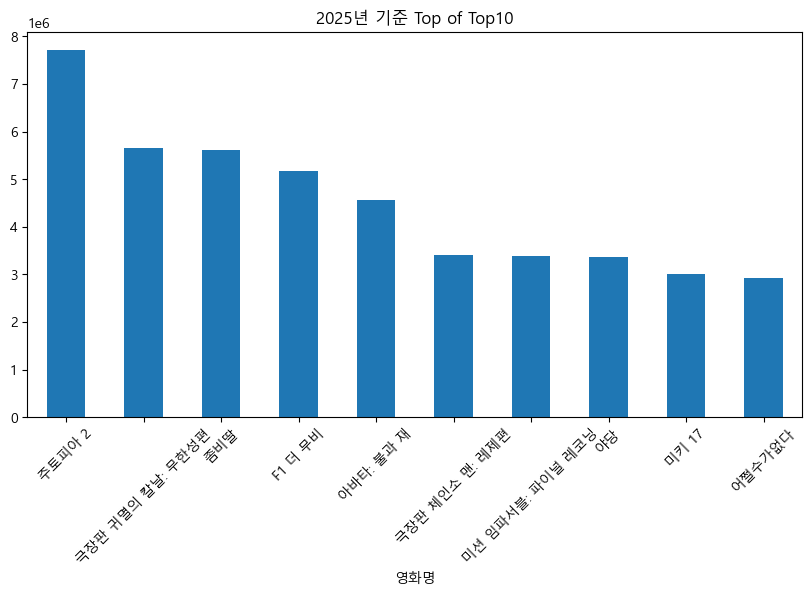

In [68]:
# 2025년 기준 Top of Top 10 그래프

df_rank1_top10.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('2025년 기준 Top of Top10')
plt.xticks(rotation=45)
plt.xlabel('영화명')
plt.show()

- 월별 총 매출액 기준 Top10
- 그래프 생성 시 월별로 정렬(1월 ~ 12월)

In [69]:
df.info()
df['일일매출액'] = df['일일매출액'].astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   object        
 2   영화명     3650 non-null   object        
 3   개봉일     3650 non-null   object        
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   object        
 6   일일매출액   3650 non-null   int64         
 7   연도      3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   object        
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 271.0+ KB


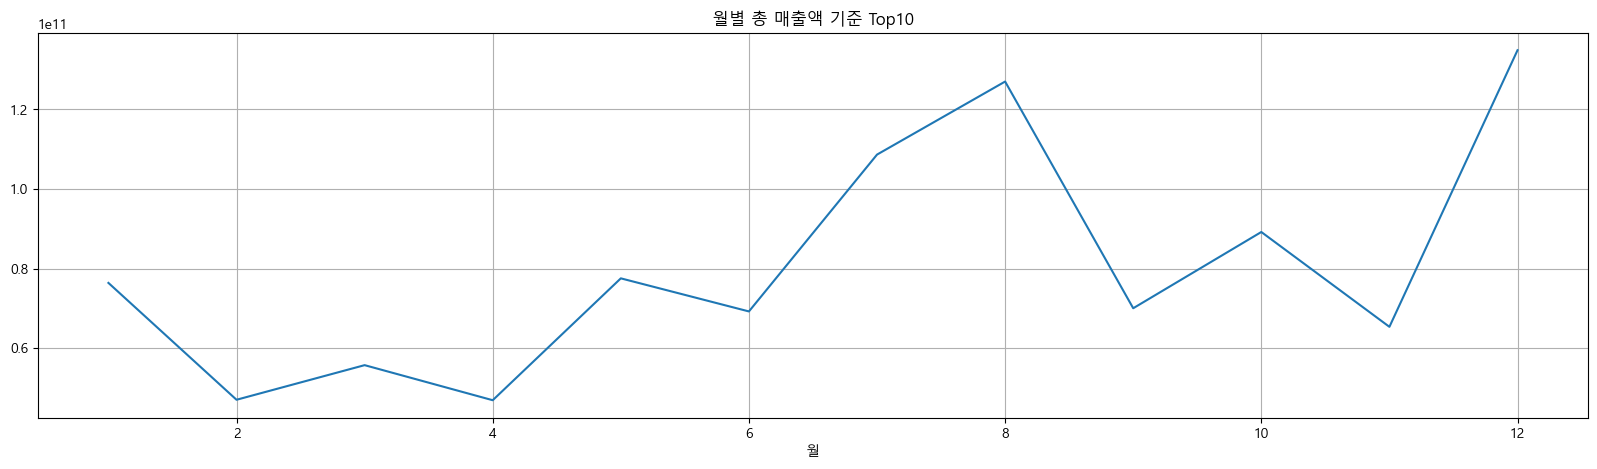

In [71]:
df_month = df.groupby('월')['일일매출액'].sum()
df_month

df_month.plot(
    kind='line',
    figsize=(20, 5)
)
plt.title('월별 총 매출액 기준 Top10')
plt.grid()
plt.show()

- 요일별 일일 관객수 추이

In [72]:
df['요일'].value_counts()

요일
수    530
목    520
금    520
토    520
일    520
월    520
화    520
Name: count, dtype: int64

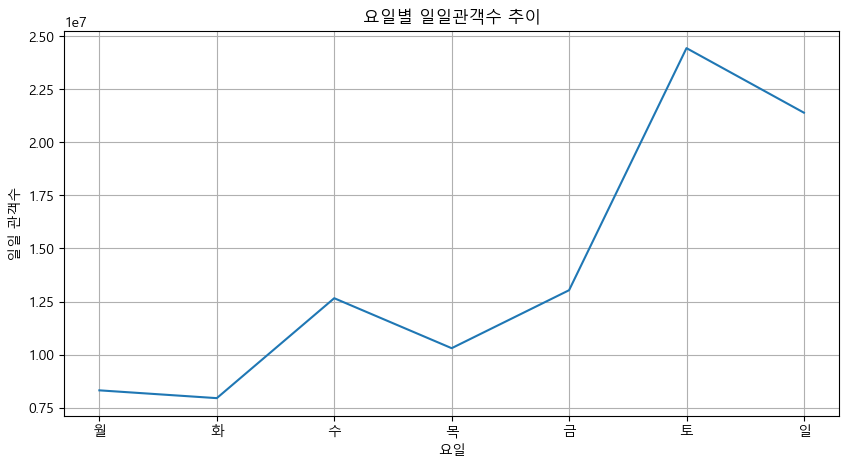

In [81]:
weekday = ['월','화','수','목','금','토','일']
df_weekday = df.groupby('요일')['일일관객수'].sum().reindex(weekday)
df_weekday

df_weekday.plot(
    kind='line',
    figsize= (10, 5)
)
plt.title('요일별 일일관객수 추이')
plt.ylabel('일일 관객수')
plt.grid()
plt.show()